# 41 — Fidelidad CONFETTI

## Descripción general

Este notebook implementa métricas de fidelidad para evaluar los contrafactuales (CFs)
generados por CONFETTI sobre un clasificador binario de inundación por tsunami
(transfer learning desde una CNN-1D).

Siguiendo los desiderata de Molnar (2023) y el paper original de CONFETTI
(Cetina et al., 2025), un CF de calidad debe cumplir 4 criterios:

| Criterio | Descripción | ¿Optimizado por CONFETTI? | ¿Reportado por CONFETTI? | ¿Reportado aquí? |
|---|---|---|---|---|
| **Cambio de clase** | El CF cambia la clase predicha | ✅ Por diseño | ✅ | ✅ |
| **Sparsity** | Se generan múltiples CFs diversos | ✅ Optimizado | ✅ | ✅ |
| **Proximity** | El CF modifica la señal lo mínimo posible | ✅ Optimizado | ❌ | ✅ |
| **Plausibility** | El CF es físicamente realista | ✅ Por diseño (NUN) | ❌ | ✅ |

CONFETTI garantiza plausibilidad *por diseño* al construir CFs con valores del NUN,
pero **no la reporta cuantitativamente**. Este notebook implementa esa evaluación
explícita.

## Decisiones metodológicas

### Proximity
Se mide como el ratio entre la distancia L2 del CF al original y la distancia L2
del NUN al original. El NUN es el cambio mínimo teórico disponible en los datos,
por lo que actúa como referencia natural (Molnar, 2023). Un ratio ≤ 1 indica que
el CF modifica menos que el NUN.

### Plausibility — métrica espectral
Se exploró inicialmente una métrica kNN euclidiana normalizada por la dispersión
intra-clase. Esta fue descartada por dos razones:
1. La distancia euclidiana en espacio aplanado (241×6=1446 features) es inadecuada
   para series de tiempo — pequeños desplazamientos temporales generan distancias
   euclidianas grandes aunque las señales sean visualmente similares.
2. Producía resultados inconsistentes con la observación visual de los CFs.

Se adoptó en cambio una **métrica espectral** basada en similitud coseno entre
el espectro de magnitudes del CF y la distribución de referencia de X_train.
Esto es físicamente motivado: las ondas de tsunami tienen frecuencias características
bien definidas (períodos dominantes de 30-60 min). Un CF que viole esa estructura
espectral es físicamente imposible, independiente de su clase predicha.

El espectro de referencia se calcula sobre la **misma ventana temporal que el CF**,
garantizando comparabilidad frecuencial sin interpolación. La ventana mínima es
61 timesteps (≥ 1 período dominante); si CONFETTI modifica una ventana mayor,
se usa la ventana completa modificada.

El umbral de plausibilidad es el percentil 5 de las similitudes intra-referencia,
calculado también sobre esa misma ventana.

### Selección del mejor CF
CONFETTI selecciona su mejor CF optimizando confianza y sparsity. Este notebook
re-evalúa todos los CFs generados con los 4 criterios y, entre los que los cumplen
simultáneamente, selecciona el de menor proximity ratio — el que modifica menos la
señal original, coherente con la definición de Molnar (2023).

## Referencias
- Molnar, C. (2023). *Interpretable Machine Learning* (3rd ed.).
- Cetina et al. (2025). Counterfactual Explainable AI Method for Deep Learning-Based
  Multivariate Time Series Classification. AAAI.

## 1. Imports y configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import keras
from pathlib import Path
from scipy.interpolate import interp1d

from xai_utils import analyze_with_confetti
from xai_utils.fidelidad_confetti import (
    detectar_zona_modificada,
    calcular_espectro_referencia,
    plausibilidad_espectral,
    plot_cf_channels,
    plot_plausibilidad_espectral,
    reporte_cf,
    evaluar_todos_cfs,
    search_best_cf,
)

# --- Paths ---
DATA_PATH           = 'DATA/'
MODEL_PATH_ORIGINAL = 'MODELS/transfer_learned_tsunami_classifier.keras'
MODEL_PATH_WRAPPED  = 'MODELS/transfer_learned_tsunami_classifier_wrapped.keras'
SAVE_PATH           = 'RESULTADOS_CONFETTI/'

# --- Parámetros CONFETTI ---
PSIZE   = 100
MAX_GEN = 200

# --- Parámetros fidelidad ---
MIN_VENTANA   = 61   # timesteps mínimos para análisis espectral (≥1 período dominante)
CHANNEL_NAMES = [f'Boya {i+1}' for i in range(6)]

print(f'Keras version: {keras.__version__}')

I0000 00:00:1782139158.871766 3237827 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782139158.913513 3237827 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782139162.087452 3237827 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Keras version: 3.14.1


## 2. Carga de datos y modelos

In [2]:
def load_pickle(p_name):
    with open(p_name, 'rb') as f:
        return pickle.load(f)

X_train = load_pickle(DATA_PATH + 'xtrain_new.pickle')
y_train = load_pickle(DATA_PATH + 'ytrain_new.pickle')
X_val   = load_pickle(DATA_PATH + 'xval_new.pickle')
y_val   = load_pickle(DATA_PATH + 'yval_new.pickle')
X_test  = load_pickle(DATA_PATH + 'xtest_new.pickle')
y_test  = load_pickle(DATA_PATH + 'ytest_new.pickle')

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}   | y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')

X_train: (4742, 241, 6) | y_train: (4742,)
X_val:   (1017, 241, 6)   | y_val:   (1017,)
X_test:  (1017, 241, 6)  | y_test:  (1017,)


In [3]:
def resize_cam_weights(cam_weights, target_length):
    """Interpola los CAM weights del espacio reducido al espacio original."""
    x_orig = np.linspace(0, 1, len(cam_weights))
    x_tgt  = np.linspace(0, 1, target_length)
    return interp1d(x_orig, cam_weights, kind='linear')(x_tgt)

@keras.saving.register_keras_serializable()
class BinaryOutputLayer(keras.layers.Layer):
    """Wrapper requerido por CONFETTI: convierte salida (n,1) → (n,2)."""
    def call(self, x):
        p1 = keras.ops.squeeze(x, axis=-1)
        p0 = 1.0 - p1
        return keras.ops.stack([p0, p1], axis=1)

# Modelo original — para CAM
model = keras.models.load_model(MODEL_PATH_ORIGINAL)

# Modelo wrapped — para CONFETTI (convierte salida a formato (n,2))
if Path(MODEL_PATH_WRAPPED).exists():
    model_wrapped = keras.models.load_model(MODEL_PATH_WRAPPED)
else:
    inputs  = model.input
    outputs = BinaryOutputLayer()(model.output)
    model_wrapped = keras.Model(inputs=inputs, outputs=outputs)
    model_wrapped.save(MODEL_PATH_WRAPPED)

# Verificación
test_preds = model_wrapped.predict(X_train[:3], verbose=0)
print(f'Shape: {test_preds.shape}  (debe ser (3, 2))')

W0000 00:00:1782139165.539584 3237878 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1782139165.612483 3237827 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Shape: (3, 2)  (debe ser (3, 2))


In [4]:
from confetti.attribution import cam

# CAM weights sobre X_train con el modelo original
training_weights = cam(model, X_data=X_train)
print(f'Shape CAM (espacio reducido): {training_weights.shape}')

# Interpolación al espacio original (241 timesteps)
n_timesteps = X_train.shape[1]
training_weights_resized = np.array([
    resize_cam_weights(w, n_timesteps) for w in training_weights
])
print(f'Shape CAM (interpolado):      {training_weights_resized.shape}')

Shape CAM (espacio reducido): (4742, 72)
Shape CAM (interpolado):      (4742, 241)


## 3. Espectro de referencia (ilustrativo)

Se calcula el espectro de referencia de X_train para la ventana mínima de 61 timesteps,
con el fin de identificar los períodos dominantes de tsunami y justificar el valor de
`MIN_VENTANA`. En el análisis de cada CF, el espectro de referencia se recalcula
sobre la ventana efectiva de ese CF específico, garantizando comparabilidad
frecuencial sin interpolación.

Top 5 períodos dominantes (serie completa, 241 timesteps):
  34.4 min
  30.1 min
  48.2 min
  40.2 min
  60.2 min

Umbral P5 por boya: [0.803  0.8023 0.8062 0.8068 0.8058 0.8074]
Umbral P5 promedio: 0.8052


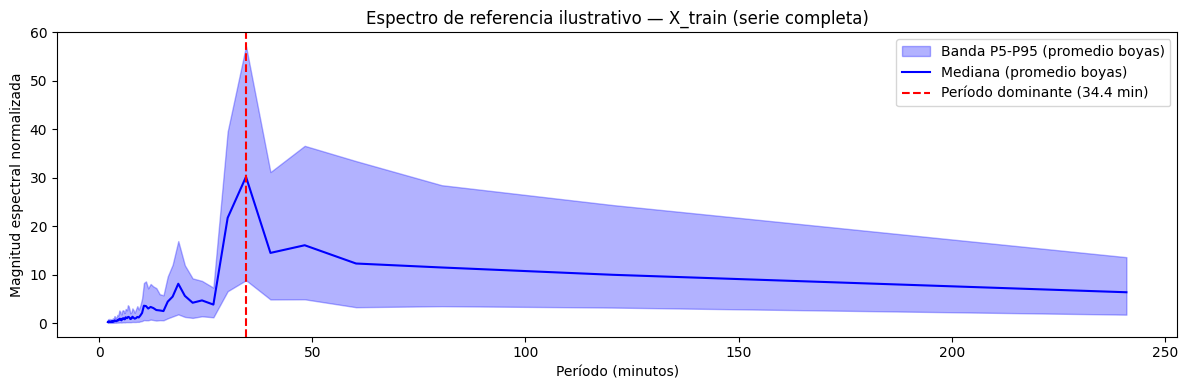

In [6]:
# Espectro ilustrativo sobre serie completa (241 timesteps)
(freqs_il, esp_med_il, esp_p5_il, esp_p95_il, _,
 esp_med_ch_il, esp_p5_ch_il, esp_p95_ch_il, umbral_ch_il) = \
    calcular_espectro_referencia(X_train, t_ini_ref=0, t_fin_ref=240)

# Frecuencias dominantes
esp_sin_dc = esp_med_il.copy(); esp_sin_dc[0] = 0
top5 = np.argsort(esp_sin_dc)[::-1][:5]
print('Top 5 períodos dominantes (serie completa, 241 timesteps):')
for idx in top5:
    if freqs_il[idx] > 0:
        print(f'  {1/freqs_il[idx]:.1f} min')

# Umbral promedio sobre las 6 boyas
print(f'\nUmbral P5 por boya: {umbral_ch_il.round(4)}')
print(f'Umbral P5 promedio: {umbral_ch_il.mean():.4f}')

# Gráfico (igual que antes, usando promedios)
periodos_il = 1.0 / freqs_il[1:]
plt.figure(figsize=(12, 4))
plt.fill_between(periodos_il, esp_p5_il[1:], esp_p95_il[1:],
                 alpha=0.3, color='blue', label='Banda P5-P95 (promedio boyas)')
plt.plot(periodos_il, esp_med_il[1:], color='blue', label='Mediana (promedio boyas)')
plt.axvline(x=1/freqs_il[top5[0]], color='red', linestyle='--',
            label=f'Período dominante ({1/freqs_il[top5[0]]:.1f} min)')
plt.xlabel('Período (minutos)')
plt.ylabel('Magnitud espectral normalizada')
plt.title('Espectro de referencia ilustrativo — X_train (serie completa)')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Caso 1: instancia clase 1 (inunda) → CF clase 0 (no inunda)

Se selecciona la primera instancia de clase 1 del set de test (idx=1).

### 4.1 Generación del CF

In [7]:
idx_inunda     = np.where(y_test == 1)[0]
instance_idx   = idx_inunda[0]
instance       = X_test[instance_idx:instance_idx+1]
original       = instance[0]
original_label = int(y_test[instance_idx])

print(f'Índice: {instance_idx} | Label real: {original_label}')

resultados_cf = analyze_with_confetti(
    model_path_wrapped=MODEL_PATH_WRAPPED,
    model_path_original=MODEL_PATH_ORIGINAL,
    instance=instance,
    training_weights_path=None,
    X_train=X_train,
    n_partitions=5, alpha=0.5, theta=0.5,
    optimize_sparsity=True, optimize_proximity=True,
    population_size=PSIZE, maximum_number_of_generations=MAX_GEN,
    feature_names=CHANNEL_NAMES, save_path=SAVE_PATH
)
results = resultados_cf['results']

cf       = results[0].best.counterfactual
cf_label = results[0].best.label
nun      = results[0].nearest_unlike_neighbour
print(f'\nContrafactual generado. Label resultante: {cf_label}')

Índice: 1 | Label real: 1
Cargando modelo original y calculando pesos CAM...
  Inicio: 10:41:52
Usando reference_weights=None

Cargando explainer CONFETTI...

Generando contrafactuales...
  Parámetros: n_partitions=5, alpha=0.5, theta=0.5, optimize_sparsity=True, population_size=100
¡Generación completada! Fin: 10:43:51
Contrafactuales generados: 36
Resultados guardados en: RESULTADOS_CONFETTI/_resultados_cf.pkl

Contrafactual generado. Label resultante: 0


### 4.2 Visualización canal por canal

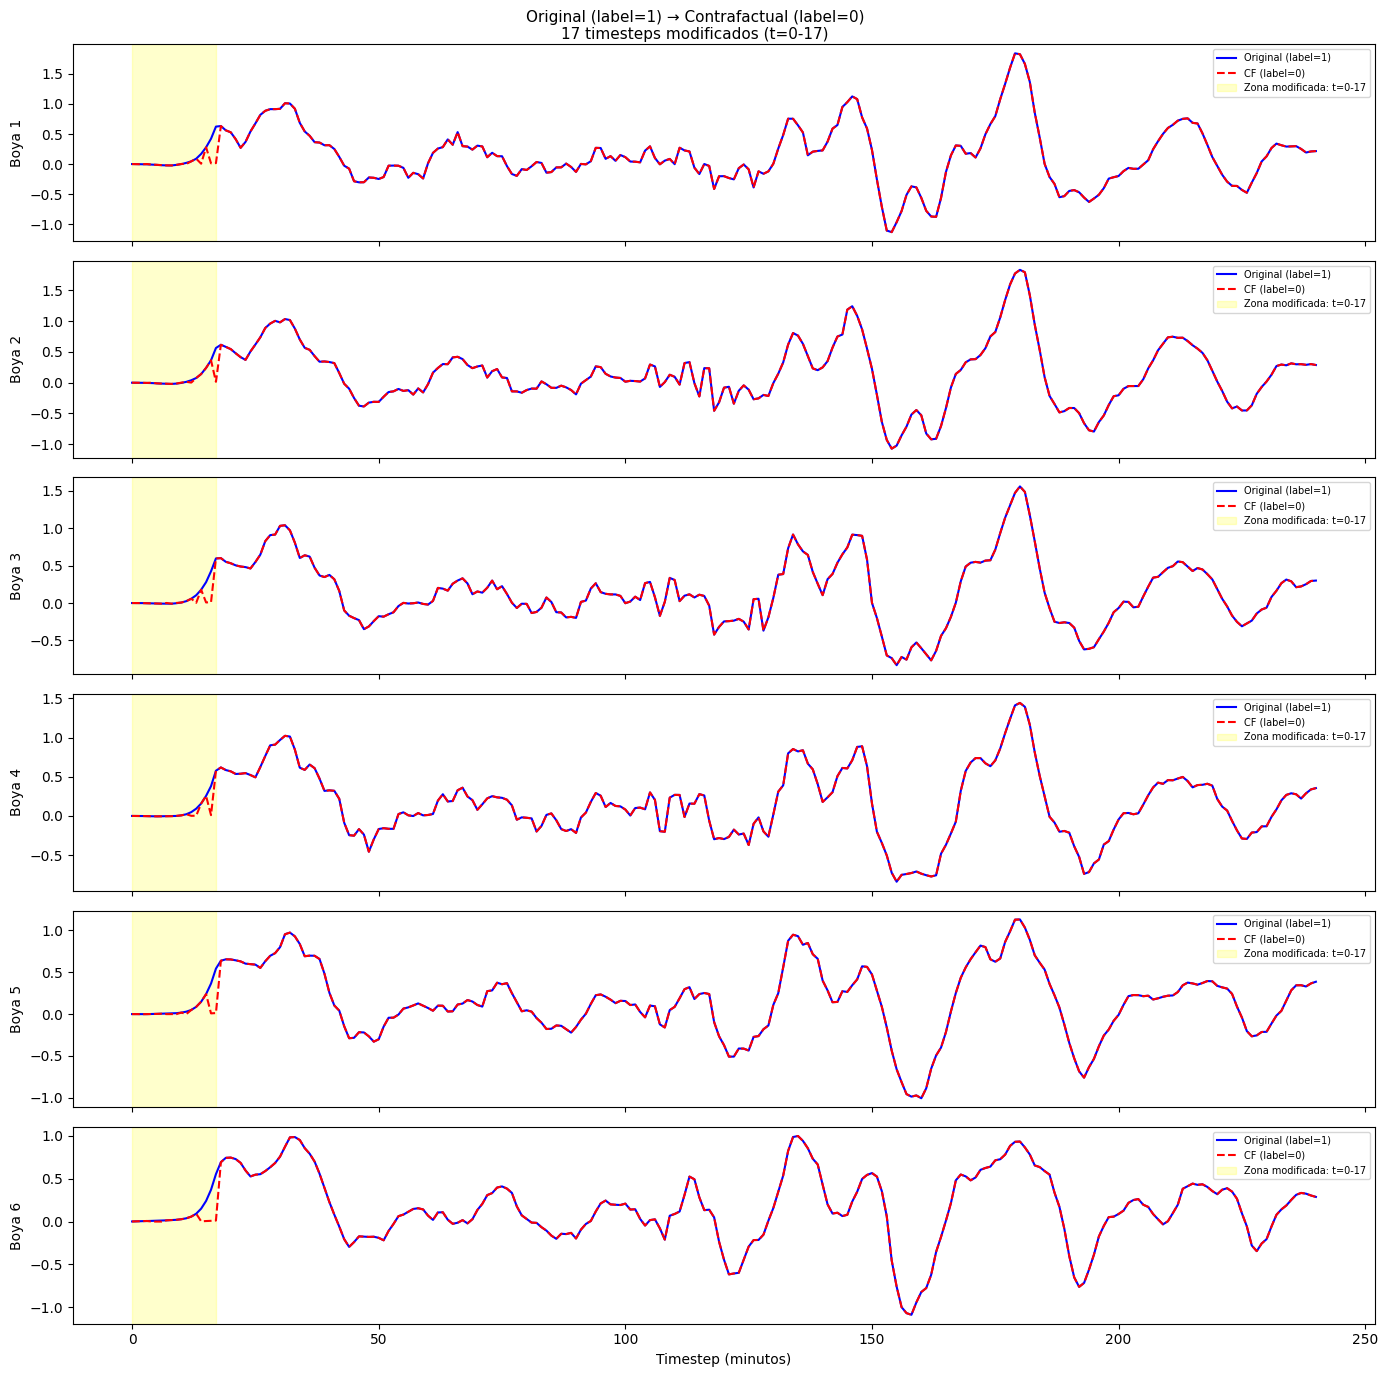

In [8]:
t_ini, t_fin, n_mod = plot_cf_channels(
    original=original, cf=cf,
    original_label=original_label, cf_label=cf_label,
    channel_names=CHANNEL_NAMES
)

### 4.3 Reporte del mejor CF según CONFETTI

In [9]:
metricas = reporte_cf(
    original=original, original_label=original_label,
    cf=cf, cf_label=cf_label,
    all_cfs=results[0].all_counterfactuals, nun=nun,
    X_train=X_train
)

        EVALUACIÓN DEL CONTRAFACTUAL

1. CAMBIO DE CLASE
   Label original:            1
   Label contrafactual:       0
   Cumple: ✅ Sí

2. SPARSITY
   CFs generados por CONFETTI:      36
   Cumple (>1 CF encontrado):       ✅ Sí

3. PROXIMITY
   Cambio CF   (L2 / energía original): 8.33%
   Cambio NUN  (L2 / energía original): 70.68%  [referencia]
   Ratio CF/NUN:                        0.1179
   Timesteps modificados (CF):  17 / 241 (7.1%)
   Timesteps distintos NUN:     241 / 241 (100.0%) [referencia]
   Cumple (ratio ≤ 1):          ✅ Sí

4. PLAUSIBILITY ESPECTRAL
   Ventana analizada: t=0-60 (61 timesteps)
   Similitud media (6 boyas):   0.9668
   Percentil medio:             79.6%
   Boya 1: sim=0.9551 (umbral=0.8582) ✅
   Boya 2: sim=0.9539 (umbral=0.8583) ✅
   Boya 3: sim=0.9706 (umbral=0.8573) ✅
   Boya 4: sim=0.9700 (umbral=0.8592) ✅
   Boya 5: sim=0.9756 (umbral=0.8642) ✅
   Boya 6: sim=0.9754 (umbral=0.8620) ✅
   Cumple (todas las boyas ≥ umbral): ✅ Sí

   RESUMEN: 4/4 crite

### 4.4 Análisis espectral del mejor CF según CONFETTI

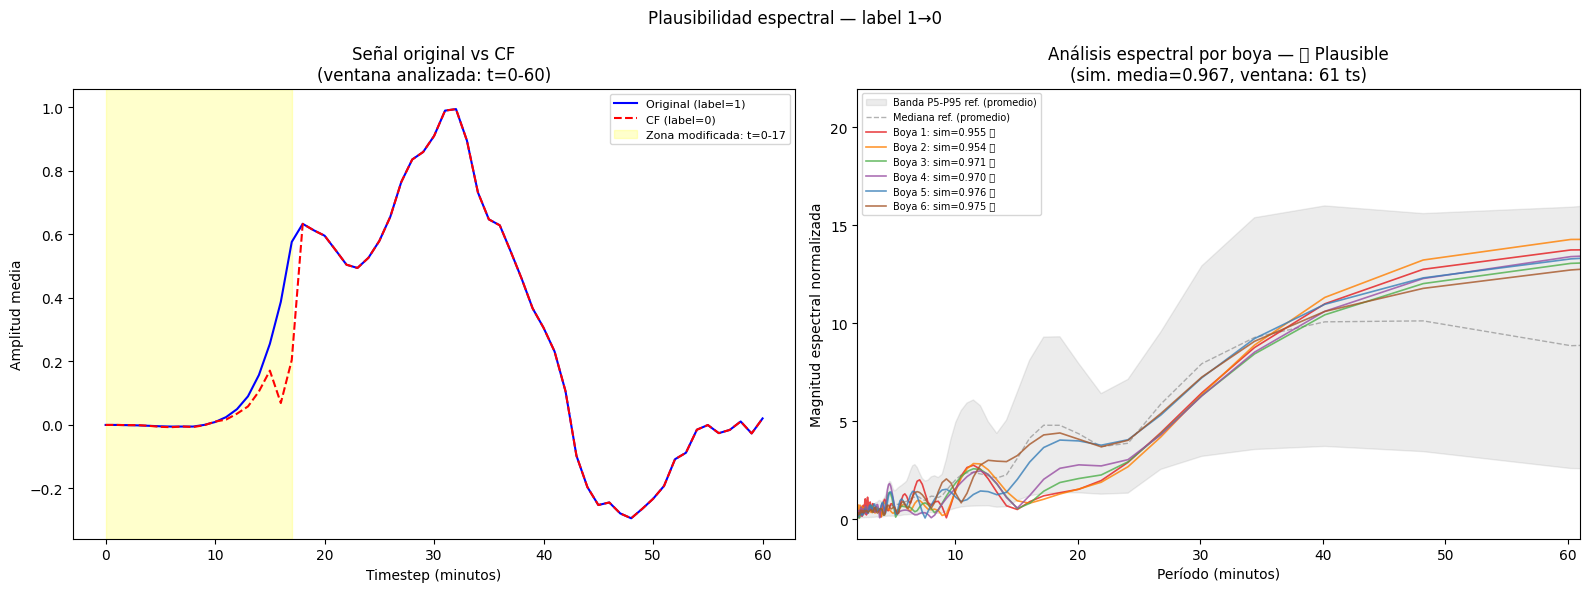

<Figure size 640x480 with 0 Axes>

In [10]:
plot_plausibilidad_espectral(
    cf=cf, original=original,
    original_label=original_label, cf_label=cf_label,
    t_ini=metricas['t_ini'],     t_fin=metricas['t_fin'],
    t_ini_exp=metricas['t_ini_exp'], t_fin_exp=metricas['t_fin_exp'],
    freqs=metricas['freqs'],     esp_median=metricas['esp_median'],
    esp_p5=metricas['esp_p5'],   esp_p95=metricas['esp_p95'],
    similitud=metricas['similitud_espectral'],
    percentil=metricas['percentil_espectral'],
    es_plausible=metricas['es_plausible'],
    similitudes_ch=metricas['similitudes_ch'],
    es_plausible_ch=metricas['es_plausible_ch'],
    umbral_p5_ch=metricas['umbral_p5_ch'],
    esp_median_ch=metricas['esp_median_ch'],
    esp_p5_ch=metricas['esp_p5_ch'],
    esp_p95_ch=metricas['esp_p95_ch'],
    channel_names=CHANNEL_NAMES
)


### 4.5 Evaluación de todos los CFs y búsqueda del mejor CF

Se re-evalúan todos los CFs generados por CONFETTI con los 4 criterios.
Entre los que cumplen simultáneamente los 4 criterios, se selecciona el de
menor proximity ratio — el que modifica menos la señal original (Molnar, 2023).

In [11]:
resultados_todos = evaluar_todos_cfs(
    all_cfs=results[0].all_counterfactuals,
    original=original, original_label=original_label, nun=nun,
    model_wrapped=model_wrapped,
    X_train=X_train
)

n_total = len(resultados_todos)
print(f'Total CFs evaluados:               {n_total}')
print(f'✅ Cambio de clase:                 {sum(r["cambio_exitoso"] for r in resultados_todos)} / {n_total}')
print(f'✅ Proximity (ratio ≤ 1):           {sum(r["cumple_proximity"] for r in resultados_todos)} / {n_total}')
print(f'✅ Plausibility espectral:          {sum(r["es_plausible"] for r in resultados_todos)} / {n_total}')
print(f'✅ Cumplen los 4 criterios:         {sum(r["cumple_4"] for r in resultados_todos)} / {n_total}')

Total CFs evaluados:               36
✅ Cambio de clase:                 36 / 36
✅ Proximity (ratio ≤ 1):           36 / 36
✅ Plausibility espectral:          36 / 36
✅ Cumplen los 4 criterios:         36 / 36


✅ Nuevo mejor CF encontrado (índice 35)
   Proximity ratio:       0.1179
   Similitud espectral:   0.9668
   Timesteps modificados: 15
        EVALUACIÓN DEL CONTRAFACTUAL

1. CAMBIO DE CLASE
   Label original:            1
   Label contrafactual:       0
   Cumple: ✅ Sí

2. SPARSITY
   CFs generados por CONFETTI:      36
   Cumple (>1 CF encontrado):       ✅ Sí

3. PROXIMITY
   Cambio CF   (L2 / energía original): 8.33%
   Cambio NUN  (L2 / energía original): 70.68%  [referencia]
   Ratio CF/NUN:                        0.1179
   Timesteps modificados (CF):  15 / 241 (6.2%)
   Timesteps distintos NUN:     241 / 241 (100.0%) [referencia]
   Cumple (ratio ≤ 1):          ✅ Sí

4. PLAUSIBILITY ESPECTRAL
   Ventana analizada: t=0-60 (61 timesteps)
   Similitud media (6 boyas):   0.9668
   Percentil medio:             79.6%
   Boya 1: sim=0.9551 (umbral=0.8582) ✅
   Boya 2: sim=0.9539 (umbral=0.8583) ✅
   Boya 3: sim=0.9706 (umbral=0.8573) ✅
   Boya 4: sim=0.9700 (umbral=0.8592) ✅
   Boya 5:

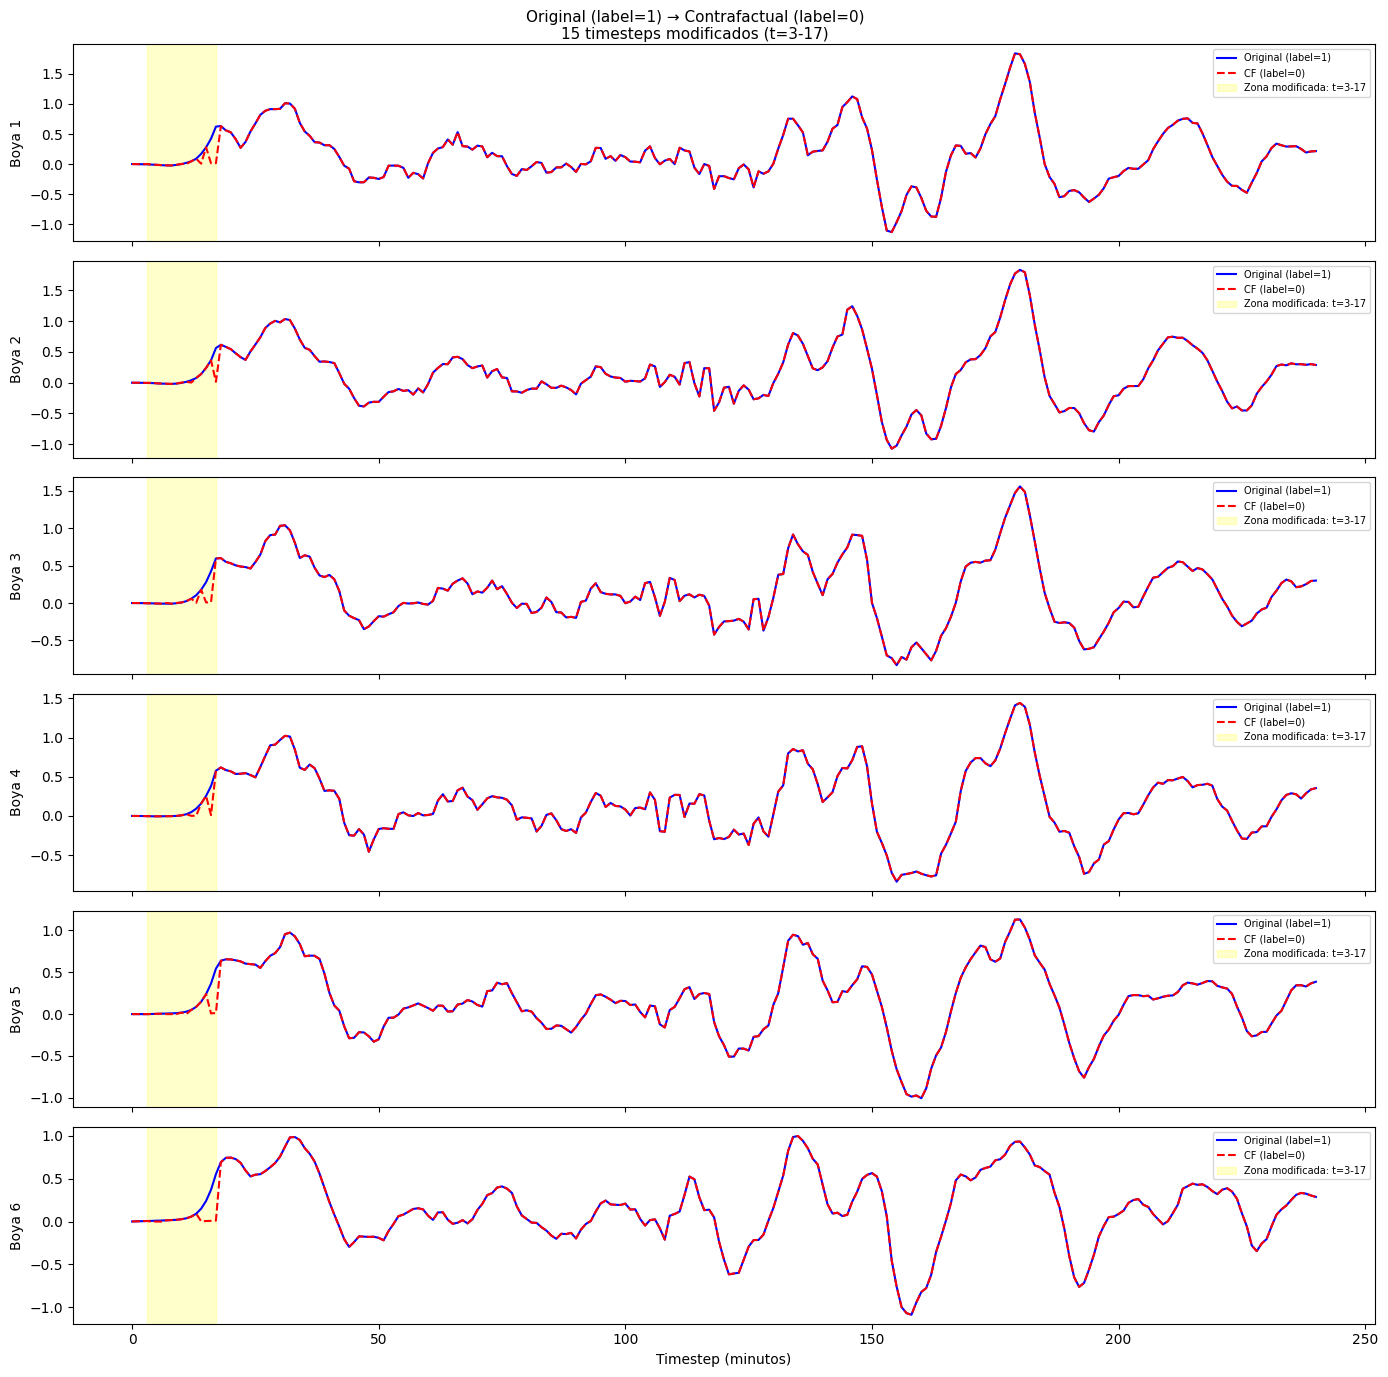

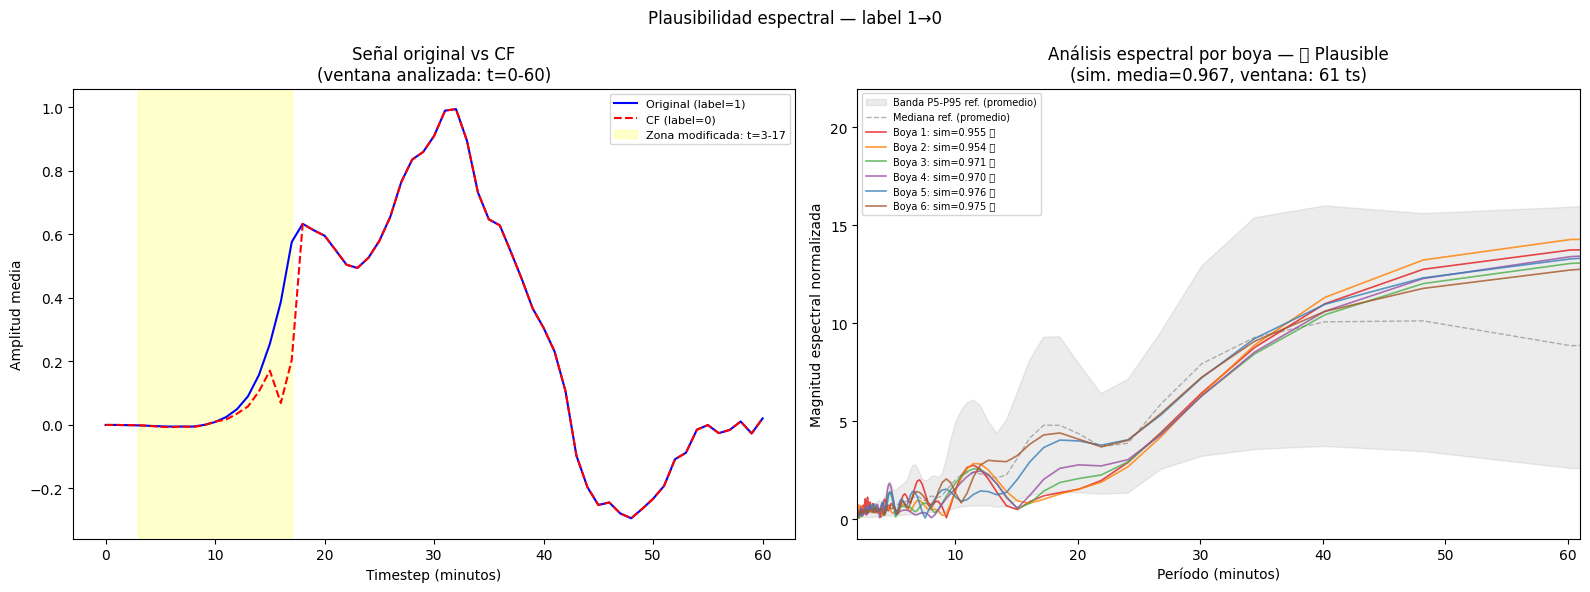

<Figure size 640x480 with 0 Axes>

In [12]:
mejor_cf = search_best_cf(resultados_todos, criterio='proximity_ratio')

if mejor_cf is None:
    print('❌ Ningún CF cumple los 4 criterios simultáneamente.')
    sims = [r['similitud_espectral'] for r in resultados_todos]
    print(f'   Similitud espectral — Min: {min(sims):.4f} | '
          f'Mediana: {np.median(sims):.4f} | Max: {max(sims):.4f}')
else:
    print(f'✅ Nuevo mejor CF encontrado (índice {mejor_cf["idx"]})')
    print(f'   Proximity ratio:       {mejor_cf["proximity_ratio"]:.4f}')
    print(f'   Similitud espectral:   {mejor_cf["similitud_espectral"]:.4f}')
    print(f'   Timesteps modificados: {mejor_cf["n_timesteps_mod"]}')

    metricas_mejor = reporte_cf(
        original=original, original_label=original_label,
        cf=mejor_cf['cf'], cf_label=mejor_cf['cf_label'],
        all_cfs=results[0].all_counterfactuals, nun=nun,
        X_train=X_train
    )
    plot_cf_channels(
        original=original, cf=mejor_cf['cf'],
        original_label=original_label, cf_label=mejor_cf['cf_label'],
        channel_names=CHANNEL_NAMES
    )
    plot_plausibilidad_espectral(
    cf=mejor_cf['cf'], original=original,
    original_label=original_label, cf_label=mejor_cf['cf_label'],
    t_ini=metricas_mejor['t_ini'],     t_fin=metricas_mejor['t_fin'],
    t_ini_exp=metricas_mejor['t_ini_exp'], t_fin_exp=metricas_mejor['t_fin_exp'],
    freqs=metricas_mejor['freqs'],     esp_median=metricas_mejor['esp_median'],
    esp_p5=metricas_mejor['esp_p5'],   esp_p95=metricas_mejor['esp_p95'],
    similitud=metricas_mejor['similitud_espectral'],
    percentil=metricas_mejor['percentil_espectral'],
    es_plausible=metricas_mejor['es_plausible'],
    similitudes_ch=metricas_mejor['similitudes_ch'],
    es_plausible_ch=metricas_mejor['es_plausible_ch'],
    umbral_p5_ch=metricas_mejor['umbral_p5_ch'],
    esp_median_ch=metricas_mejor['esp_median_ch'],
    esp_p5_ch=metricas_mejor['esp_p5_ch'],
    esp_p95_ch=metricas_mejor['esp_p95_ch'],
    channel_names=CHANNEL_NAMES
)


## 5. Caso 2: instancia clase 0 (no inunda) → CF clase 1 (inunda)

Se selecciona la primera instancia de clase 0 del set de test (idx=0).

### 5.1 Generación del CF

In [13]:
idx_no_inunda    = np.where(y_test == 0)[0]
instance_idx_2   = idx_no_inunda[0]
instance_2       = X_test[instance_idx_2:instance_idx_2+1]
original_2       = instance_2[0]
original_label_2 = int(y_test[instance_idx_2])

print(f'Índice: {instance_idx_2} | Label real: {original_label_2}')

resultados_cf_2 = analyze_with_confetti(
    model_path_wrapped=MODEL_PATH_WRAPPED,
    model_path_original=MODEL_PATH_ORIGINAL,
    instance=instance_2,
    training_weights_path=None,
    X_train=X_train,
    n_partitions=5, alpha=0.5, theta=0.5,
    optimize_sparsity=True, optimize_proximity=True,
    population_size=PSIZE, maximum_number_of_generations=MAX_GEN,
    feature_names=CHANNEL_NAMES, save_path=SAVE_PATH
)
results_2 = resultados_cf_2['results']

cf_2       = results_2[0].best.counterfactual
cf_label_2 = results_2[0].best.label
nun_2      = results_2[0].nearest_unlike_neighbour
print(f'\nContrafactual generado. Label resultante: {cf_label_2}')

Índice: 0 | Label real: 0
Cargando modelo original y calculando pesos CAM...
  Inicio: 10:45:02
Usando reference_weights=None

Cargando explainer CONFETTI...

Generando contrafactuales...
  Parámetros: n_partitions=5, alpha=0.5, theta=0.5, optimize_sparsity=True, population_size=100
¡Generación completada! Fin: 10:46:53
Contrafactuales generados: 35
Resultados guardados en: RESULTADOS_CONFETTI/_resultados_cf.pkl

Contrafactual generado. Label resultante: 1


### 5.2 Visualización canal por canal

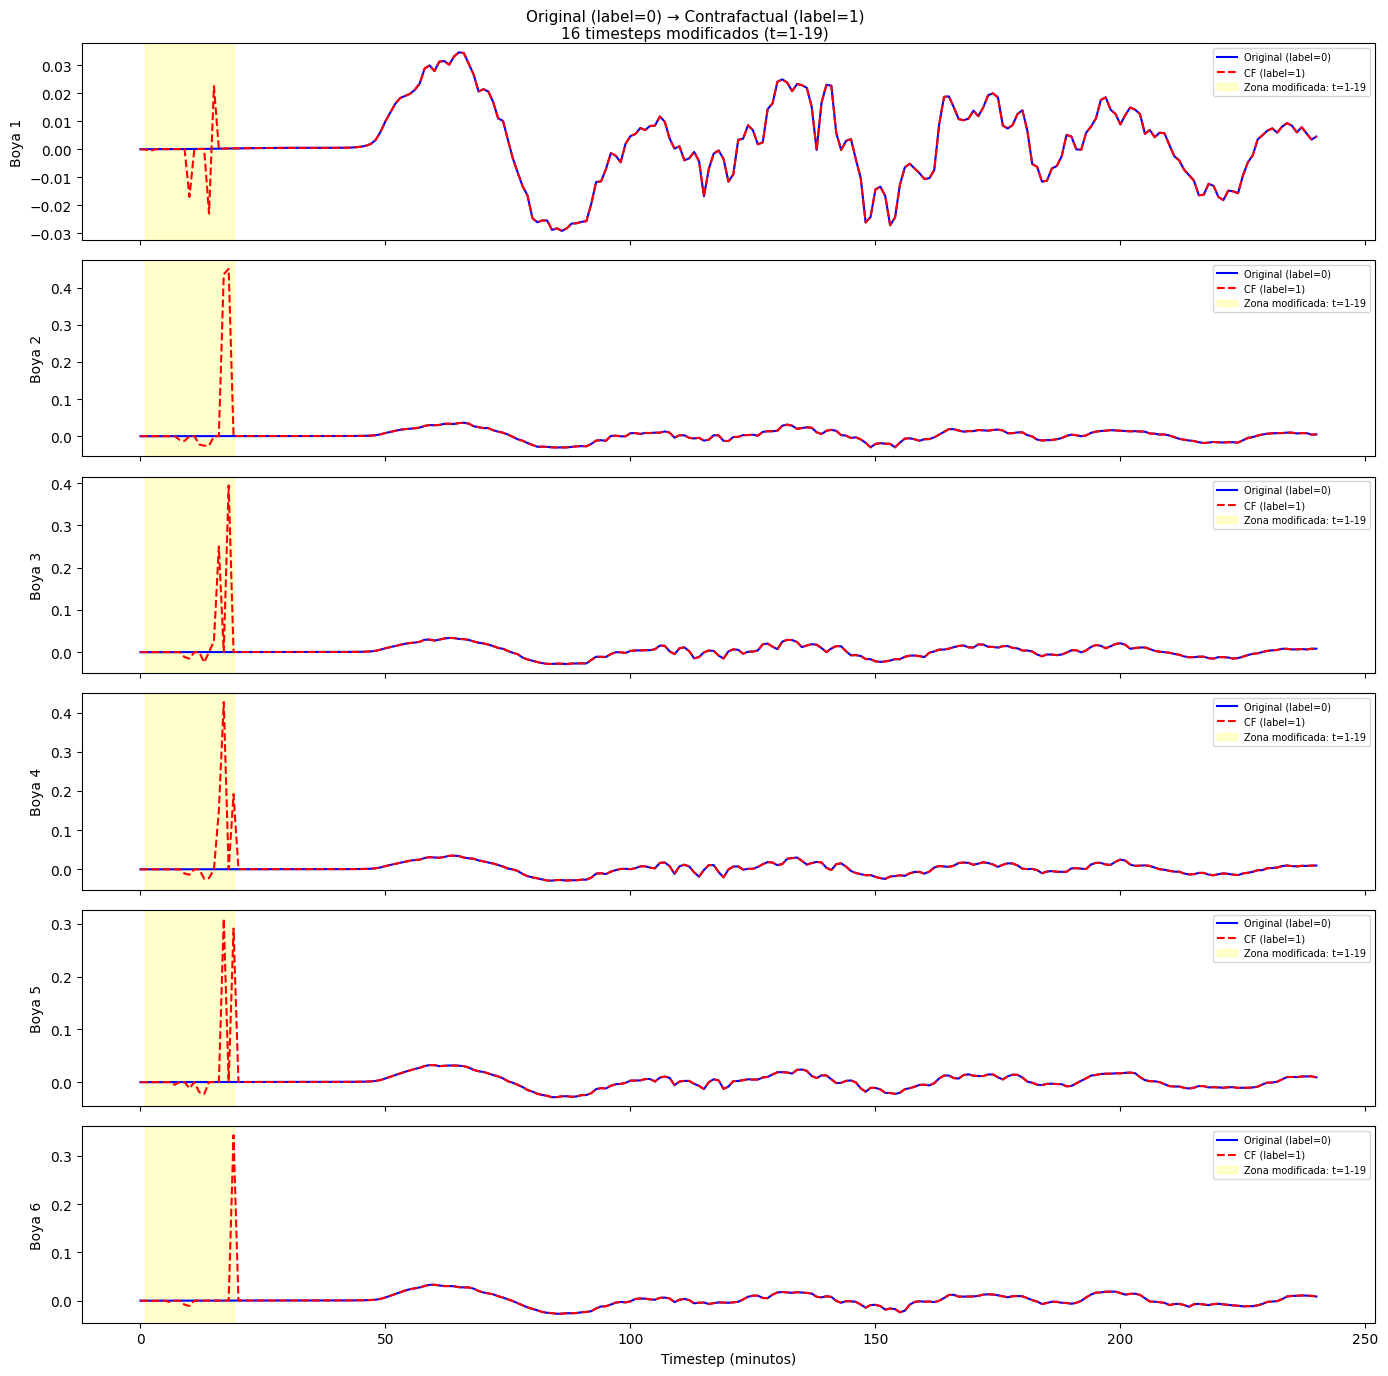

(1, 19, 16)

In [14]:
plot_cf_channels(
    original=original_2, cf=cf_2,
    original_label=original_label_2, cf_label=cf_label_2,
    channel_names=CHANNEL_NAMES
)

### 5.3 Reporte del mejor CF según CONFETTI

In [15]:
metricas_2 = reporte_cf(
    original=original_2, original_label=original_label_2,
    cf=cf_2, cf_label=cf_label_2,
    all_cfs=results_2[0].all_counterfactuals, nun=nun_2,
    X_train=X_train
)

        EVALUACIÓN DEL CONTRAFACTUAL

1. CAMBIO DE CLASE
   Label original:            0
   Label contrafactual:       1
   Cumple: ✅ Sí

2. SPARSITY
   CFs generados por CONFETTI:      35
   Cumple (>1 CF encontrado):       ✅ Sí

3. PROXIMITY
   Cambio CF   (L2 / energía original): 211.71%
   Cambio NUN  (L2 / energía original): 780.06%  [referencia]
   Ratio CF/NUN:                        0.2714
   Timesteps modificados (CF):  16 / 241 (6.6%)
   Timesteps distintos NUN:     240 / 241 (99.6%) [referencia]
   Cumple (ratio ≤ 1):          ✅ Sí

4. PLAUSIBILITY ESPECTRAL
   Ventana analizada: t=0-60 (61 timesteps)
   Similitud media (6 boyas):   0.6761
   Percentil medio:             4.3%
   Boya 1: sim=0.9127 (umbral=0.8582) ✅
   Boya 2: sim=0.6621 (umbral=0.8583) ❌
   Boya 3: sim=0.6314 (umbral=0.8573) ❌
   Boya 4: sim=0.6828 (umbral=0.8592) ❌
   Boya 5: sim=0.6239 (umbral=0.8642) ❌
   Boya 6: sim=0.5439 (umbral=0.8620) ❌
   Cumple (todas las boyas ≥ umbral): ❌ No

   RESUMEN: 3/4 crit

### 5.4 Análisis espectral del mejor CF según CONFETTI

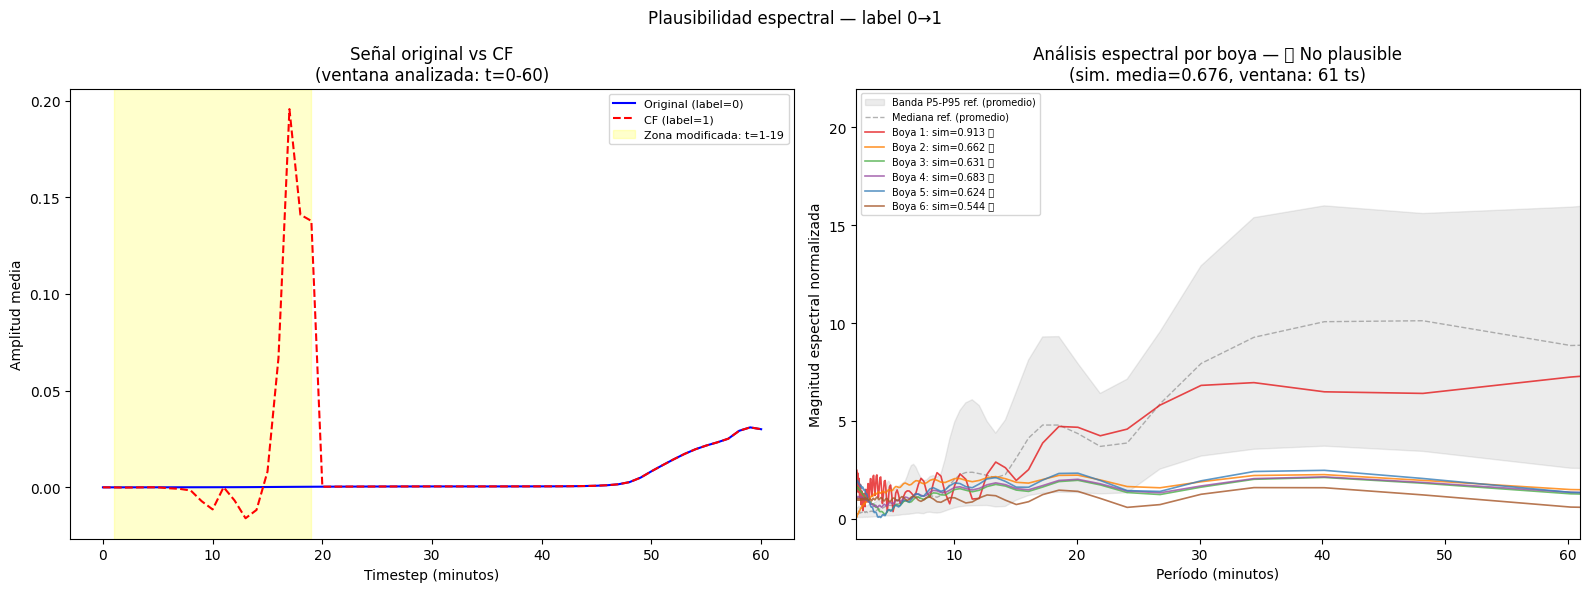

<Figure size 640x480 with 0 Axes>

In [16]:
plot_plausibilidad_espectral(
    cf=cf_2, original=original_2,
    original_label=original_label_2, cf_label=cf_label_2,
    t_ini=metricas_2['t_ini'],     t_fin=metricas_2['t_fin'],
    t_ini_exp=metricas_2['t_ini_exp'], t_fin_exp=metricas_2['t_fin_exp'],
    freqs=metricas_2['freqs'],     esp_median=metricas_2['esp_median'],
    esp_p5=metricas_2['esp_p5'],   esp_p95=metricas_2['esp_p95'],
    similitud=metricas_2['similitud_espectral'],
    percentil=metricas_2['percentil_espectral'],
    es_plausible=metricas_2['es_plausible'],
    similitudes_ch=metricas_2['similitudes_ch'],
    es_plausible_ch=metricas_2['es_plausible_ch'],
    umbral_p5_ch=metricas_2['umbral_p5_ch'],
    esp_median_ch=metricas_2['esp_median_ch'],
    esp_p5_ch=metricas_2['esp_p5_ch'],
    esp_p95_ch=metricas_2['esp_p95_ch'],
    channel_names=CHANNEL_NAMES
)


### 5.5 Evaluación de todos los CFs y búsqueda del mejor CF

In [17]:
resultados_todos_2 = evaluar_todos_cfs(
    all_cfs=results_2[0].all_counterfactuals,
    original=original_2, original_label=original_label_2, nun=nun_2,
    model_wrapped=model_wrapped,
    X_train=X_train
)

n_total_2 = len(resultados_todos_2)
print(f'Total CFs evaluados:               {n_total_2}')
print(f'✅ Cambio de clase:                 {sum(r["cambio_exitoso"] for r in resultados_todos_2)} / {n_total_2}')
print(f'✅ Proximity (ratio ≤ 1):           {sum(r["cumple_proximity"] for r in resultados_todos_2)} / {n_total_2}')
print(f'✅ Plausibility espectral:          {sum(r["es_plausible"] for r in resultados_todos_2)} / {n_total_2}')
print(f'✅ Cumplen los 4 criterios:         {sum(r["cumple_4"] for r in resultados_todos_2)} / {n_total_2}')

Total CFs evaluados:               35
✅ Cambio de clase:                 35 / 35
✅ Proximity (ratio ≤ 1):           35 / 35
✅ Plausibility espectral:          0 / 35
✅ Cumplen los 4 criterios:         0 / 35


In [18]:
mejor_cf_2 = search_best_cf(resultados_todos_2, criterio='proximity_ratio')

if mejor_cf_2 is None:
    print('❌ Ningún CF cumple los 4 criterios simultáneamente.')
    sims_2 = [r['similitud_espectral'] for r in resultados_todos_2]
    print(f'   Similitud espectral — Min: {min(sims_2):.4f} | '
          f'Mediana: {np.median(sims_2):.4f} | Max: {max(sims_2):.4f}')
else:
    print(f'✅ Nuevo mejor CF encontrado (índice {mejor_cf_2["idx"]})')
    print(f'   Proximity ratio:       {mejor_cf_2["proximity_ratio"]:.4f}')
    print(f'   Similitud espectral:   {mejor_cf_2["similitud_espectral"]:.4f}')
    print(f'   Timesteps modificados: {mejor_cf_2["n_timesteps_mod"]}')

    metricas_mejor_2 = reporte_cf(
        original=original_2, original_label=original_label_2,
        cf=mejor_cf_2['cf'], cf_label=mejor_cf_2['cf_label'],
        all_cfs=results_2[0].all_counterfactuals, nun=nun_2,
        X_train=X_train
    )
    plot_cf_channels(
        original=original_2, cf=mejor_cf_2['cf'],
        original_label=original_label_2, cf_label=mejor_cf_2['cf_label'],
        channel_names=CHANNEL_NAMES
    )
    plot_plausibilidad_espectral(
    cf=mejor_cf_2['cf'], original=original_2,
    original_label=original_label_2, cf_label=mejor_cf_2['cf_label'],
    t_ini=metricas_mejor_2['t_ini'],     t_fin=metricas_mejor_2['t_fin'],
    t_ini_exp=metricas_mejor_2['t_ini_exp'], t_fin_exp=metricas_mejor_2['t_fin_exp'],
    freqs=metricas_mejor_2['freqs'],     esp_median=metricas_mejor_2['esp_median'],
    esp_p5=metricas_mejor_2['esp_p5'],   esp_p95=metricas_mejor_2['esp_p95'],
    similitud=metricas_mejor_2['similitud_espectral'],
    percentil=metricas_mejor_2['percentil_espectral'],
    es_plausible=metricas_mejor_2['es_plausible'],
    similitudes_ch=metricas_mejor_2['similitudes_ch'],
    es_plausible_ch=metricas_mejor_2['es_plausible_ch'],
    umbral_p5_ch=metricas_mejor_2['umbral_p5_ch'],
    esp_median_ch=metricas_mejor_2['esp_median_ch'],
    esp_p5_ch=metricas_mejor_2['esp_p5_ch'],
    esp_p95_ch=metricas_mejor_2['esp_p95_ch'],
    channel_names=CHANNEL_NAMES
)


❌ Ningún CF cumple los 4 criterios simultáneamente.
   Similitud espectral — Min: 0.5927 | Mediana: 0.6662 | Max: 0.7170


## 6. Instancias con predicción incierta (probabilidad entre 0.4 y 0.6)

Se analizan instancias donde el modelo es inseguro en su predicción. Para estas
instancias se espera que el CF requiera cambios mínimos para cruzar el umbral
de decisión, lo que debería reflejarse en mejores valores de proximity.

In [25]:
# Instancias con predicción incierta — bien clasificadas
probs_test  = model.predict(X_test, verbose=0).flatten()
mask_unc    = (probs_test >= 0.) & (probs_test <= 0.01)
idx_unc     = np.where(mask_unc)[0]

print('Instancias con predicción entre 0.4 y 0.6:')
for idx in idx_unc:
    prob       = probs_test[idx]
    pred_label = 1 if prob >= 0.5 else 0
    label_real = y_test[idx]
    correcta   = '✅' if pred_label == label_real else '❌'
    print(f'  idx={idx} | prob={prob:.4f} | pred={pred_label} | real={label_real} | {correcta}')

Instancias con predicción entre 0.4 y 0.6:
  idx=0 | prob=0.0083 | pred=0 | real=0 | ✅
  idx=2 | prob=0.0081 | pred=0 | real=0 | ✅
  idx=7 | prob=0.0082 | pred=0 | real=0 | ✅
  idx=13 | prob=0.0094 | pred=0 | real=0 | ✅
  idx=17 | prob=0.0069 | pred=0 | real=0 | ✅
  idx=25 | prob=0.0074 | pred=0 | real=0 | ✅
  idx=30 | prob=0.0088 | pred=0 | real=0 | ✅
  idx=31 | prob=0.0076 | pred=0 | real=0 | ✅
  idx=32 | prob=0.0077 | pred=0 | real=0 | ✅
  idx=33 | prob=0.0094 | pred=0 | real=0 | ✅
  idx=34 | prob=0.0088 | pred=0 | real=0 | ✅
  idx=35 | prob=0.0081 | pred=0 | real=0 | ✅
  idx=38 | prob=0.0095 | pred=0 | real=0 | ✅
  idx=47 | prob=0.0080 | pred=0 | real=0 | ✅
  idx=54 | prob=0.0080 | pred=0 | real=0 | ✅
  idx=57 | prob=0.0082 | pred=0 | real=0 | ✅
  idx=63 | prob=0.0092 | pred=0 | real=0 | ✅
  idx=74 | prob=0.0097 | pred=0 | real=0 | ✅
  idx=75 | prob=0.0094 | pred=0 | real=0 | ✅
  idx=76 | prob=0.0081 | pred=0 | real=0 | ✅
  idx=77 | prob=0.0081 | pred=0 | real=0 | ✅
  idx=79 | prob

### 6.1 Análisis de instancia incierta

*(Seleccionar una instancia bien clasificada del listado anterior y aplicar
el mismo flujo de las secciones 4 y 5)*

Índice: 1003 | Label real: 0
Cargando modelo original y calculando pesos CAM...
  Inicio: 13:04:17
Usando reference_weights=None

Cargando explainer CONFETTI...

Generando contrafactuales...
  Parámetros: n_partitions=5, alpha=0.5, theta=0.5, optimize_sparsity=True, population_size=100
¡Generación completada! Fin: 13:06:09
Contrafactuales generados: 34
Resultados guardados en: RESULTADOS_CONFETTI/_resultados_cf.pkl

Contrafactual generado. Label resultante: 1


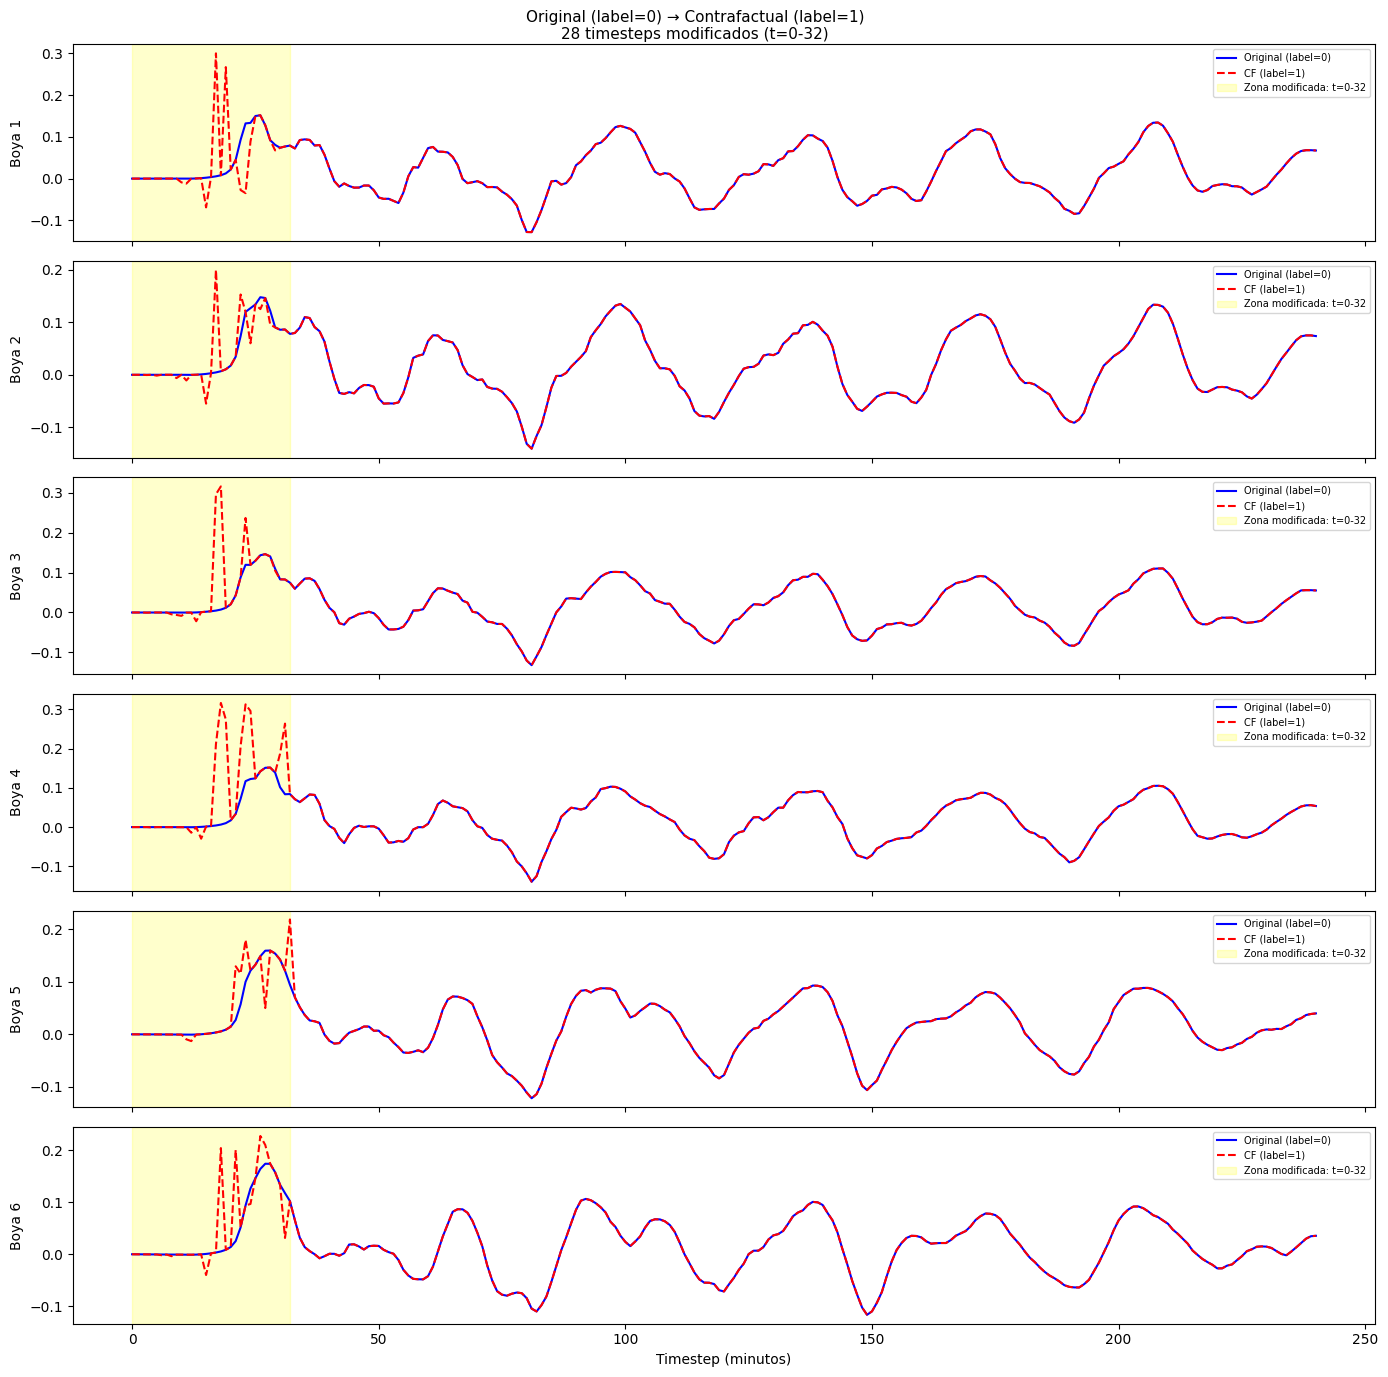

(0, 32, 28)

In [26]:
idx = 1003
instance_3       = X_test[idx:idx+1]
original_3       = instance_3[0]
original_label_3 = int(y_test[idx])

print(f'Índice: {idx} | Label real: {original_label_3}')

resultados_cf_3 = analyze_with_confetti(
    model_path_wrapped=MODEL_PATH_WRAPPED,
    model_path_original=MODEL_PATH_ORIGINAL,
    instance=instance_3,
    training_weights_path=None,
    X_train=X_train,
    n_partitions=5, alpha=0.5, theta=0.5,
    optimize_sparsity=True, optimize_proximity=True,
    population_size=PSIZE, maximum_number_of_generations=MAX_GEN,
    feature_names=CHANNEL_NAMES, save_path=SAVE_PATH
)
results_3 = resultados_cf_3['results']

cf_3       = results_3[0].best.counterfactual
cf_label_3 = results_3[0].best.label
nun_3      = results_3[0].nearest_unlike_neighbour
print(f'\nContrafactual generado. Label resultante: {cf_label_3}')

plot_cf_channels(
    original=original_3, cf=cf_3,
    original_label=original_label_3, cf_label=cf_label_3,
    channel_names=CHANNEL_NAMES
)

In [27]:
metricas_3 = reporte_cf(
    original=original_3, original_label=original_label_3,
    cf=cf_3, cf_label=cf_label_3,
    all_cfs=results_3[0].all_counterfactuals, nun=nun_3,
    X_train=X_train, min_ventana=60
)

        EVALUACIÓN DEL CONTRAFACTUAL

1. CAMBIO DE CLASE
   Label original:            0
   Label contrafactual:       1
   Cumple: ✅ Sí

2. SPARSITY
   CFs generados por CONFETTI:      34
   Cumple (>1 CF encontrado):       ✅ Sí

3. PROXIMITY
   Cambio CF   (L2 / energía original): 42.63%
   Cambio NUN  (L2 / energía original): 179.12%  [referencia]
   Ratio CF/NUN:                        0.2380
   Timesteps modificados (CF):  28 / 241 (11.6%)
   Timesteps distintos NUN:     241 / 241 (100.0%) [referencia]
   Cumple (ratio ≤ 1):          ✅ Sí

4. PLAUSIBILITY ESPECTRAL
   Ventana analizada: t=0-59 (60 timesteps)
   Similitud media (6 boyas):   0.9012
   Percentil medio:             26.5%
   Boya 1: sim=0.8288 (umbral=0.8591) ❌
   Boya 2: sim=0.9266 (umbral=0.8578) ✅
   Boya 3: sim=0.8826 (umbral=0.8561) ✅
   Boya 4: sim=0.9194 (umbral=0.8568) ✅
   Boya 5: sim=0.9482 (umbral=0.8622) ✅
   Boya 6: sim=0.9016 (umbral=0.8618) ✅
   Cumple (todas las boyas ≥ umbral): ❌ No

   RESUMEN: 3/4 cr

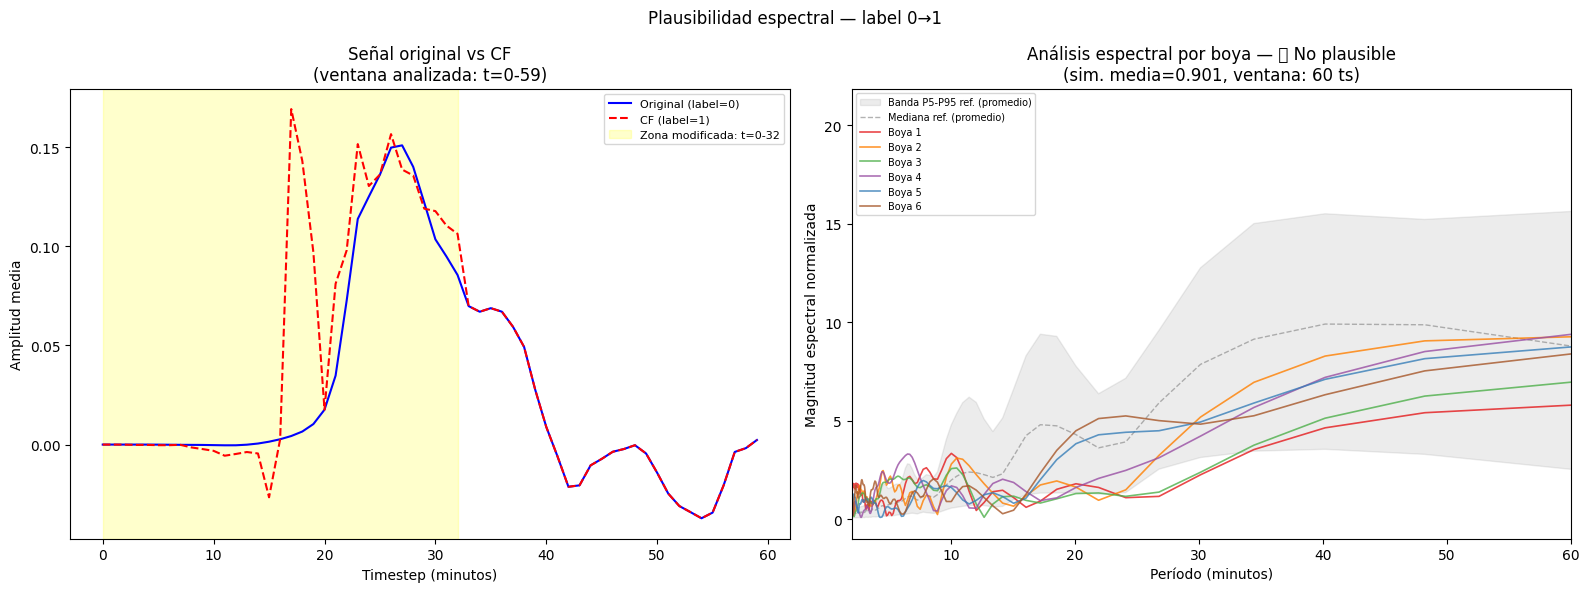

<Figure size 640x480 with 0 Axes>

In [28]:
plot_plausibilidad_espectral(
    cf=cf_3, original=original_3,
    original_label=original_label_3, cf_label=cf_label_3,
    t_ini=metricas_3['t_ini'],     t_fin=metricas_3['t_fin'],
    t_ini_exp=metricas_3['t_ini_exp'], t_fin_exp=metricas_3['t_fin_exp'],
    freqs=metricas_3['freqs'],     esp_median=metricas_3['esp_median'],
    esp_p5=metricas_3['esp_p5'],   esp_p95=metricas_3['esp_p95'],
    similitud=metricas_3['similitud_espectral'],
    percentil=metricas_3['percentil_espectral'],
    es_plausible=metricas_3['es_plausible']
)

In [29]:
resultados_todos_3 = evaluar_todos_cfs(
    all_cfs=results_3[0].all_counterfactuals,
    original=original_3, original_label=original_label_3, nun=nun_3,
    model_wrapped=model_wrapped,
    X_train=X_train
)

n_total_3 = len(resultados_todos_3)
print(f'Total CFs evaluados:               {n_total_3}')
print(f'✅ Cambio de clase:                 {sum(r["cambio_exitoso"] for r in resultados_todos_3)} / {n_total_3}')
print(f'✅ Proximity (ratio ≤ 1):           {sum(r["cumple_proximity"] for r in resultados_todos_3)} / {n_total_3}')
print(f'✅ Plausibility espectral:          {sum(r["es_plausible"] for r in resultados_todos_3)} / {n_total_3}')
print(f'✅ Cumplen los 4 criterios:         {sum(r["cumple_4"] for r in resultados_todos_3)} / {n_total_3}')

Total CFs evaluados:               34
✅ Cambio de clase:                 34 / 34
✅ Proximity (ratio ≤ 1):           34 / 34
✅ Plausibility espectral:          17 / 34
✅ Cumplen los 4 criterios:         17 / 34


✅ Nuevo mejor CF encontrado (índice 27)
   Proximity ratio:       0.1681
   Similitud espectral:   0.9271
   Timesteps modificados: 23
        EVALUACIÓN DEL CONTRAFACTUAL

1. CAMBIO DE CLASE
   Label original:            0
   Label contrafactual:       1
   Cumple: ✅ Sí

2. SPARSITY
   CFs generados por CONFETTI:      34
   Cumple (>1 CF encontrado):       ✅ Sí

3. PROXIMITY
   Cambio CF   (L2 / energía original): 30.11%
   Cambio NUN  (L2 / energía original): 179.12%  [referencia]
   Ratio CF/NUN:                        0.1681
   Timesteps modificados (CF):  23 / 241 (9.5%)
   Timesteps distintos NUN:     241 / 241 (100.0%) [referencia]
   Cumple (ratio ≤ 1):          ✅ Sí

4. PLAUSIBILITY ESPECTRAL
   Ventana analizada: t=0-60 (61 timesteps)
   Similitud media (6 boyas):   0.9271
   Percentil medio:             40.2%
   Boya 1: sim=0.9497 (umbral=0.8582) ✅
   Boya 2: sim=0.8972 (umbral=0.8583) ✅
   Boya 3: sim=0.9545 (umbral=0.8573) ✅
   Boya 4: sim=0.9448 (umbral=0.8592) ✅
   Boya 

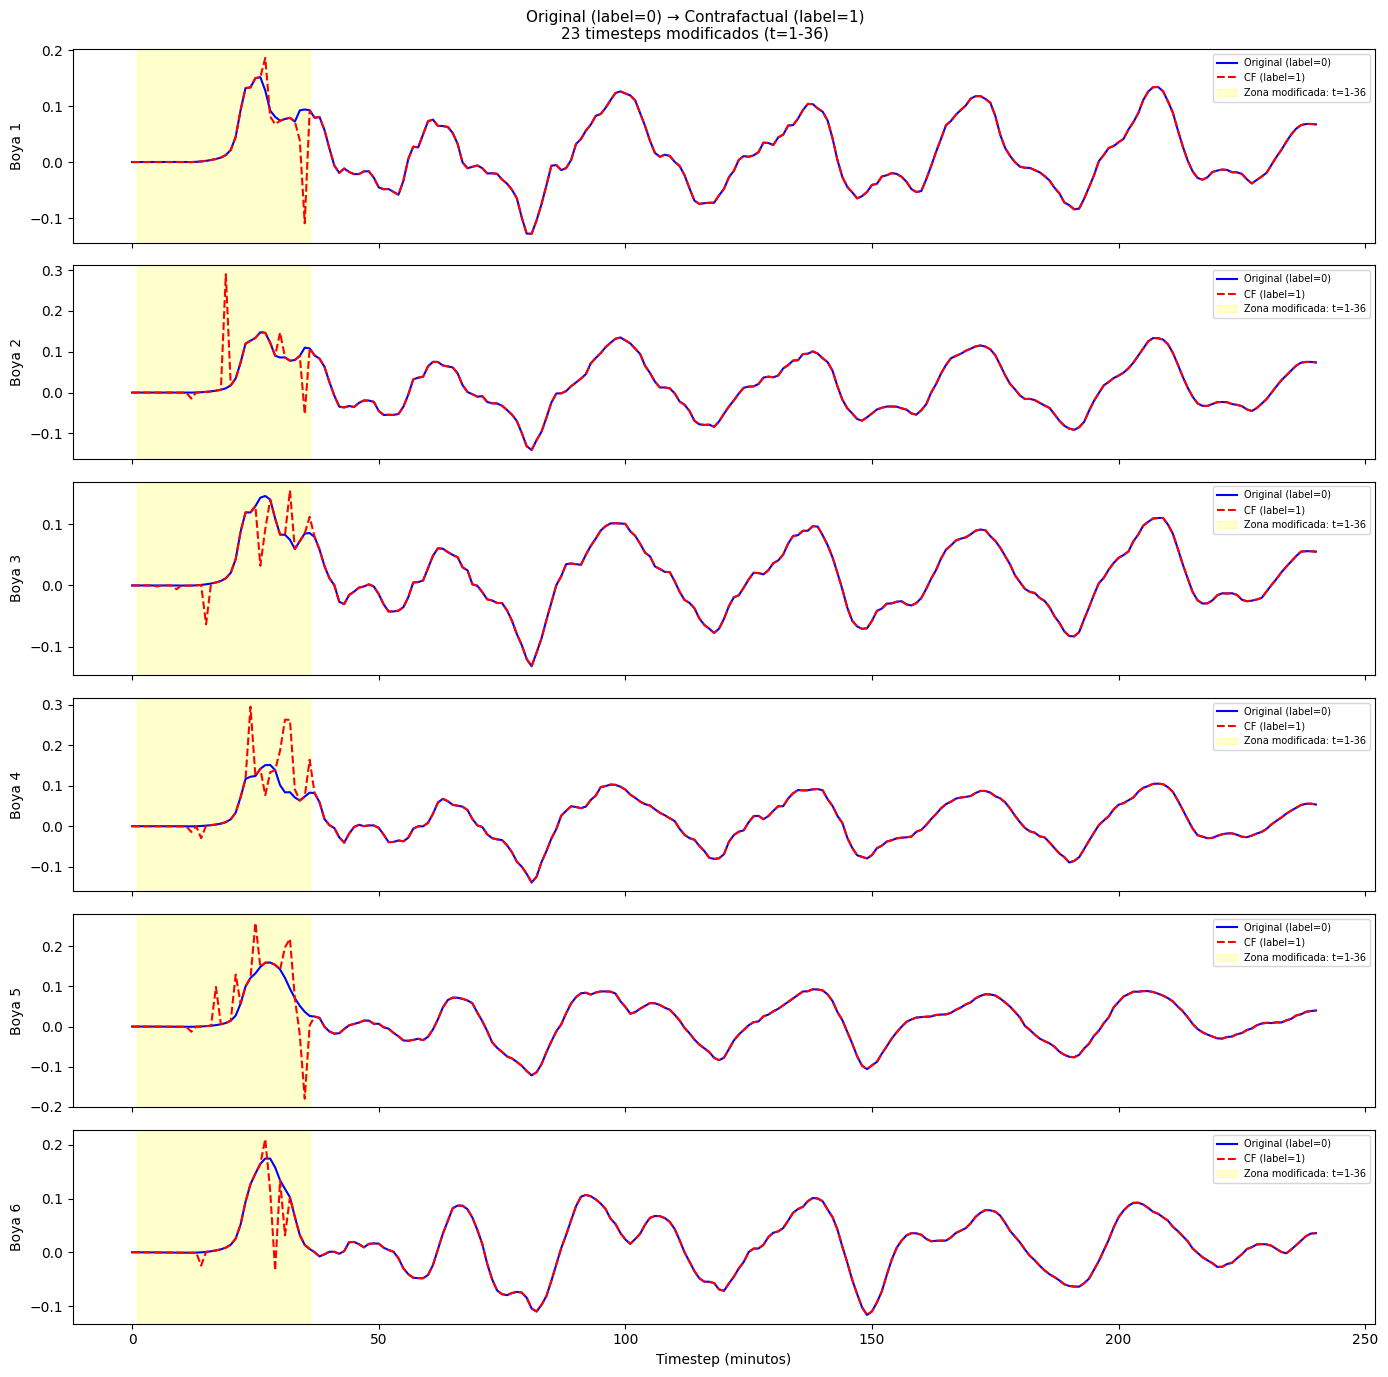

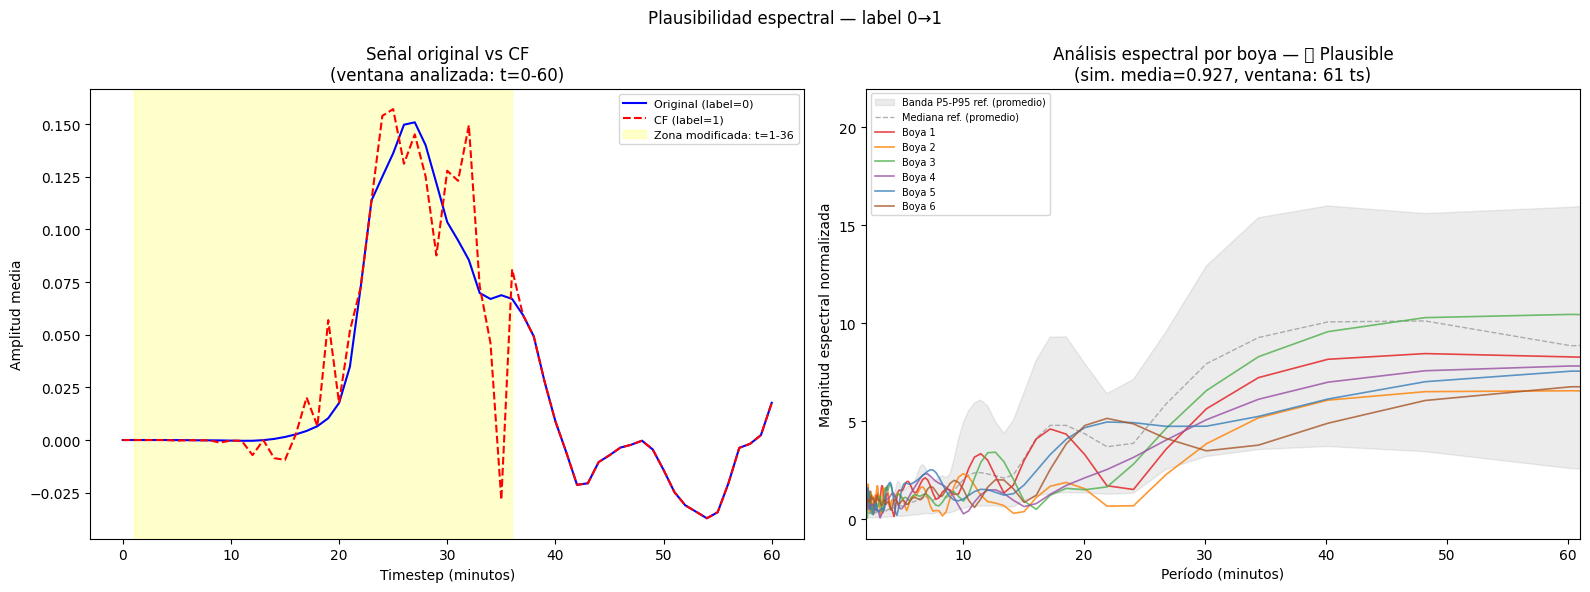

<Figure size 640x480 with 0 Axes>

In [30]:
mejor_cf_3 = search_best_cf(resultados_todos_3, criterio='proximity_ratio')

if mejor_cf_3 is None:
    print('❌ Ningún CF cumple los 4 criterios simultáneamente.')
    sims_3 = [r['similitud_espectral'] for r in resultados_todos_3]
    print(f'   Similitud espectral — Min: {min(sims_3):.4f} | '
          f'Mediana: {np.median(sims_3):.4f} | Max: {max(sims_3):.4f}')
else:
    print(f'✅ Nuevo mejor CF encontrado (índice {mejor_cf_3["idx"]})')
    print(f'   Proximity ratio:       {mejor_cf_3["proximity_ratio"]:.4f}')
    print(f'   Similitud espectral:   {mejor_cf_3["similitud_espectral"]:.4f}')
    print(f'   Timesteps modificados: {mejor_cf_3["n_timesteps_mod"]}')

    metricas_mejor_3 = reporte_cf(
        original=original_3, original_label=original_label_3,
        cf=mejor_cf_3['cf'], cf_label=mejor_cf_3['cf_label'],
        all_cfs=results_3[0].all_counterfactuals, nun=nun_3,
        X_train=X_train
    )
    plot_cf_channels(
        original=original_3, cf=mejor_cf_3['cf'],
        original_label=original_label_3, cf_label=mejor_cf_3['cf_label'],
        channel_names=CHANNEL_NAMES
    )
    plot_plausibilidad_espectral(
        cf=mejor_cf_3['cf'], original=original_3,
        original_label=original_label_3, cf_label=mejor_cf_3['cf_label'],
        t_ini=metricas_mejor_3['t_ini'],     t_fin=metricas_mejor_3['t_fin'],
        t_ini_exp=metricas_mejor_3['t_ini_exp'], t_fin_exp=metricas_mejor_3['t_fin_exp'],
        freqs=metricas_mejor_3['freqs'],     esp_median=metricas_mejor_3['esp_median'],
        esp_p5=metricas_mejor_3['esp_p5'],   esp_p95=metricas_mejor_3['esp_p95'],
        similitud=metricas_mejor_3['similitud_espectral'],
        percentil=metricas_mejor_3['percentil_espectral'],
        es_plausible=metricas_mejor_3['es_plausible']
    )

# Análisis sobre un conjunto de instancias

In [33]:
import time

np.random.seed(42)

# --- Selección de muestra: 5 seguras + 5 inciertas por clase ---
probs_test = model.predict(X_test, verbose=0).flatten()

# Instancias "seguras" (predicción confiable)
idx_seguras_1 = np.where((probs_test > 0.8)  & (y_test == 1))[0]
idx_seguras_0 = np.where((probs_test < 0.2)  & (y_test == 0))[0]

# Instancias "inciertas" bien clasificadas
idx_inc_1 = np.where((probs_test >= 0.5) & (probs_test <= 0.7) & (y_test == 1))[0]
idx_inc_0 = np.where((probs_test >= 0.3) & (probs_test <= 0.5) & (y_test == 0))[0]

muestra_1 = np.concatenate([
    np.random.choice(idx_seguras_1, size=min(5, len(idx_seguras_1)), replace=False),
    np.random.choice(idx_inc_1,     size=min(5, len(idx_inc_1)),     replace=False)
])
muestra_0 = np.concatenate([
    np.random.choice(idx_seguras_0, size=min(5, len(idx_seguras_0)), replace=False),
    np.random.choice(idx_inc_0,     size=min(5, len(idx_inc_0)),     replace=False)
])

print(f"Muestra clase 1 (inunda):    {muestra_1} ({len(muestra_1)} instancias)")
print(f"Muestra clase 0 (no inunda): {muestra_0} ({len(muestra_0)} instancias)")

Muestra clase 1 (inunda):    [ 543 1009   78  569  252  166  371   72  979  795] (10 instancias)
Muestra clase 0 (no inunda): [933 841 937  63 224 329 691 732 794  62] (10 instancias)


In [34]:
def analizar_muestra(indices, X_test, y_test, X_train,
                     model_wrapped, MODEL_PATH_WRAPPED, MODEL_PATH_ORIGINAL,
                     CHANNEL_NAMES, SAVE_PATH, PSIZE, MAX_GEN):
    """
    Itera sobre una muestra de instancias, genera CFs y evalúa métricas.
    Retorna un resumen tabulado.
    """
    resultados = []

    for i, idx in enumerate(indices):
        print(f"\n{'='*55}")
        print(f"Instancia {i+1}/{len(indices)} — idx={idx} | "
              f"label={y_test[idx]} | prob={model.predict(X_test[idx:idx+1], verbose=0).flatten()[0]:.3f}")
        print('='*55)

        instance       = X_test[idx:idx+1]
        original       = instance[0]
        original_label = int(y_test[idx])
        t0 = time.time()

        # Generar CF
        try:
            res_cf = analyze_with_confetti(
                model_path_wrapped=MODEL_PATH_WRAPPED,
                model_path_original=MODEL_PATH_ORIGINAL,
                instance=instance,
                training_weights_path=None,
                X_train=X_train,
                n_partitions=5, alpha=0.5, theta=0.5,
                optimize_sparsity=True, optimize_proximity=True,
                population_size=PSIZE, maximum_number_of_generations=MAX_GEN,
                feature_names=CHANNEL_NAMES, save_path=SAVE_PATH,
                verbose=False
            )
            results = res_cf['results']

            if results[0].best is None:
                print("❌ No se encontró CF válido")
                resultados.append({'idx': idx, 'label': original_label,
                                   'cf_encontrado': False})
                continue

            cf       = results[0].best.counterfactual
            cf_label = results[0].best.label
            nun      = results[0].nearest_unlike_neighbour

            # Evaluar métricas
            met = reporte_cf(
                original=original, original_label=original_label,
                cf=cf, cf_label=cf_label,
                all_cfs=results[0].all_counterfactuals, nun=nun,
                X_train=X_train
            )

            # Buscar nuevo mejor CF
            todos = evaluar_todos_cfs(
                all_cfs=results[0].all_counterfactuals,
                original=original, original_label=original_label, nun=nun,
                model_wrapped=model_wrapped, X_train=X_train
            )
            mejor = search_best_cf(todos, criterio='proximity_ratio')

            t_total = time.time() - t0
            n_plausibles = sum(r['es_plausible'] for r in todos)

            resultados.append({
                'idx':                idx,
                'label':              original_label,
                'prob':               model.predict(X_test[idx:idx+1], verbose=0).flatten()[0],
                'cf_encontrado':      True,
                'n_cfs':              len(todos),
                'n_plausibles':       n_plausibles,
                # Mejor CF según CONFETTI
                'confetti_4criterios':  all([met['cambio_exitoso'], met['cumple_sparsity'],
                                             met['cumple_proximity'], met['es_plausible']]),
                'confetti_proximity':   met['proximity_ratio'],
                'confetti_similitud':   met['similitud_espectral'],
                'confetti_plausible':   met['es_plausible'],
                # Nuevo mejor CF
                'nuevo_mejor_idx':    mejor['idx'] if mejor else None,
                'nuevo_mejor_prox':   mejor['proximity_ratio'] if mejor else None,
                'nuevo_mejor_sim':    mejor['similitud_espectral'] if mejor else None,
                'nuevo_mejor_existe': mejor is not None,
                'tiempo_s':           t_total,
            })
            print(f"\n⏱ Tiempo: {t_total:.1f}s | "
                  f"CFs plausibles: {n_plausibles}/{len(todos)} | "
                  f"Nuevo mejor: {'✅' if mejor else '❌'}")

        except Exception as e:
            print(f"❌ Error: {e}")
            resultados.append({'idx': idx, 'label': original_label,
                               'cf_encontrado': False, 'error': str(e)})

    return resultados

In [35]:
# Ejecutar sobre la muestra
print("Analizando clase 1 (inunda)...")
res_clase1 = analizar_muestra(
    muestra_1, X_test, y_test, X_train,
    model_wrapped, MODEL_PATH_WRAPPED, MODEL_PATH_ORIGINAL,
    CHANNEL_NAMES, SAVE_PATH, PSIZE, MAX_GEN
)

print("\n\nAnalizando clase 0 (no inunda)...")
res_clase0 = analizar_muestra(
    muestra_0, X_test, y_test, X_train,
    model_wrapped, MODEL_PATH_WRAPPED, MODEL_PATH_ORIGINAL,
    CHANNEL_NAMES, SAVE_PATH, PSIZE, MAX_GEN
)

Analizando clase 1 (inunda)...

Instancia 1/10 — idx=543 | label=1 | prob=0.982
Cargando modelo original y calculando pesos CAM...
  Inicio: 13:15:41
Usando reference_weights=None

Cargando explainer CONFETTI...

Generando contrafactuales...
  Parámetros: n_partitions=5, alpha=0.5, theta=0.5, optimize_sparsity=True, population_size=100
¡Generación completada! Fin: 13:17:47
Contrafactuales generados: 21
Resultados guardados en: RESULTADOS_CONFETTI/_resultados_cf.pkl
        EVALUACIÓN DEL CONTRAFACTUAL

1. CAMBIO DE CLASE
   Label original:            1
   Label contrafactual:       0
   Cumple: ✅ Sí

2. SPARSITY
   CFs generados por CONFETTI:      21
   Cumple (>1 CF encontrado):       ✅ Sí

3. PROXIMITY
   Cambio CF   (L2 / energía original): 15.59%
   Cambio NUN  (L2 / energía original): 48.69%  [referencia]
   Ratio CF/NUN:                        0.3202
   Timesteps modificados (CF):  67 / 241 (27.8%)
   Timesteps distintos NUN:     241 / 241 (100.0%) [referencia]
   Cumple (ratio ≤

In [36]:
# Resumen tabulado
import pandas as pd

df1 = pd.DataFrame([r for r in res_clase1 if r.get('cf_encontrado')])
df0 = pd.DataFrame([r for r in res_clase0 if r.get('cf_encontrado')])

cols = ['idx', 'label', 'prob', 'n_cfs', 'n_plausibles',
        'confetti_plausible', 'confetti_proximity', 'confetti_similitud',
        'nuevo_mejor_existe', 'nuevo_mejor_prox', 'tiempo_s']

print("\n=== CLASE 1 (inunda) ===")
print(pd.concat([df1, df0])[cols].to_string(index=False))


=== CLASE 1 (inunda) ===
 idx  label     prob  n_cfs  n_plausibles  confetti_plausible  confetti_proximity  confetti_similitud  nuevo_mejor_existe  nuevo_mejor_prox   tiempo_s
 543      1 0.982045     21            21                True            0.320171            0.965945                True          0.285890 167.087252
1009      1 1.000000     53            36                True            0.297145            0.888181                True          0.118628 209.686904
  78      1 1.000000     39            39                True            0.141656            0.972090                True          0.137769 183.887936
 569      1 0.999991     45            45                True            0.224729            0.879375                True          0.100675 196.700042
 252      1 1.000000     49             1               False            0.355500            0.839162                True          0.332184 205.223516
 166      1 0.608827     43            43                True       

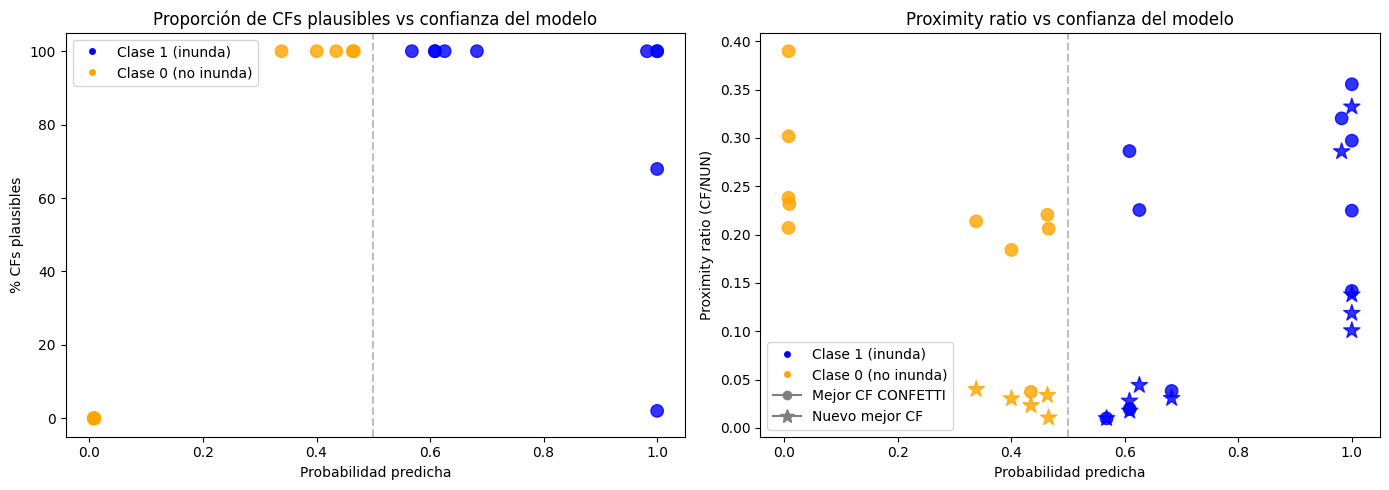

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.DataFrame([r for r in res_clase1 + res_clase0 if r.get('cf_encontrado')])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: proporción de CFs plausibles vs probabilidad predicha
ax = axes[0]
df['pct_plausibles'] = df['n_plausibles'] / df['n_cfs'] * 100
colores = ['blue' if l == 1 else 'orange' for l in df['label']]
ax.scatter(df['prob'], df['pct_plausibles'], c=colores, s=80, alpha=0.8)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('% CFs plausibles')
ax.set_title('Proporción de CFs plausibles vs confianza del modelo')
from matplotlib.lines import Line2D
leyenda = [Line2D([0],[0], marker='o', color='w', markerfacecolor='blue', label='Clase 1 (inunda)'),
           Line2D([0],[0], marker='o', color='w', markerfacecolor='orange', label='Clase 0 (no inunda)')]
ax.legend(handles=leyenda)

# Panel derecho: proximity ratio del mejor CF vs probabilidad
ax = axes[1]
ax.scatter(df['prob'], df['confetti_proximity'], c=colores, s=80, alpha=0.8,
           label='Mejor CF CONFETTI')
ax.scatter(df[df['nuevo_mejor_existe']]['prob'],
           df[df['nuevo_mejor_existe']]['nuevo_mejor_prox'],
           c=[colores[i] for i in df[df['nuevo_mejor_existe']].index],
           marker='*', s=150, alpha=0.8, label='Nuevo mejor CF')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Proximity ratio (CF/NUN)')
ax.set_title('Proximity ratio vs confianza del modelo')
ax.legend(handles=leyenda + [
    Line2D([0],[0], marker='o', color='gray', label='Mejor CF CONFETTI'),
    Line2D([0],[0], marker='*', color='gray', markersize=10, label='Nuevo mejor CF')
])

plt.tight_layout()
plt.show()

In [38]:
print(df[['idx', 'label', 'prob', 'n_plausibles', 'confetti_plausible']].to_string())
print(f"\nClase 0: {(df['label']==0).sum()} instancias")
print(f"Clase 1: {(df['label']==1).sum()} instancias")

     idx  label      prob  n_plausibles  confetti_plausible
0    543      1  0.982045            21                True
1   1009      1  1.000000            36                True
2     78      1  1.000000            39                True
3    569      1  0.999991            45                True
4    252      1  1.000000             1               False
5    166      1  0.608827            43                True
6    371      1  0.625759            50                True
7     72      1  0.608313            47                True
8    979      1  0.682569            49                True
9    795      1  0.567975            36                True
10   933      0  0.007756             0               False
11   841      0  0.008126             0               False
12   937      0  0.007757             0               False
13    63      0  0.009203             0               False
14   224      0  0.007945             0               False
15   329      0  0.434749            24 